## Plots and Charts of the Performance of the SPLADE Models

In [ ]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
RESULTS_DIR = 'results'
OUTPUT_FILE = 'full_results_master.csv'

print(f"Starting Data Aggregation")
print(f"Looking for CSV files in directory: '{RESULTS_DIR}'...")
# Use glob to find all .csv files recursively inside the results folder.
# The pattern '**/*.csv' matches any csv in any subdirectory of results.
csv_files = glob.glob(os.path.join(RESULTS_DIR, '**', '*.csv'), recursive=True)

print(f"Found {len(csv_files)} CSV files. Reading them now...")

# READ AND COLLECT DATA
dataframes = []
for file_path in csv_files:

    # FILTERING LOGIC
    # Ignore paths containing 'ft_scifact_lam'
    if "ft_scifact_lam" in file_path:
        print(f"Skipping ignored model path: {file_path}")
        continue
    try:
        df_temp = pd.read_csv(file_path)
        
        # EXTRACT MODEL NAME FROM FOLDER
        # Get the parent folder name (which represents the Model)
        # Example: results/splade_distil/scidocs.csv -> splade_distil
        parent_folder = os.path.dirname(file_path)
        model_name = os.path.basename(parent_folder)
        
        # Add/Overwrite the 'Model' column with the folder name
        df_temp['Model'] = model_name
        
        # (Optional) Verify consistency here if needed
        dataframes.append(df_temp)
        
    except Exception as e:
        print(f"Error reading file {file_path}: {e}")

# COMBINE DATA
if dataframes:
    # Concatenate all snippets into one large Master DataFrame
    full_df = pd.concat(dataframes, ignore_index=True)
    
    print("\nAggregation Success!")
    print(f"Total rows collected: {len(full_df)}")
    print(f"Total columns: {len(full_df.columns)}")
    
    print("\nUnique Models Detected")
    print(full_df['Model'].unique())

    print("\nUnique Datasets Detected")
    if 'Dataset' in full_df.columns:
        print(full_df['Dataset'].unique())
    else:
        print("Warning: 'Dataset' column not found.")

Starting Data Aggregation
Looking for CSV files in directory: 'results'...
Found 41 CSV files. Reading them now...
Skipping ignored model path: results\ft_scifact_lam0.0008\fiqa_results.csv
Skipping ignored model path: results\ft_scifact_lam0.0008\scidocs_results.csv
Skipping ignored model path: results\ft_scifact_lam0.0008\scifact_results.csv
Skipping ignored model path: results\ft_scifact_lam0.008\fiqa_results.csv
Skipping ignored model path: results\ft_scifact_lam0.008\scidocs_results.csv
Skipping ignored model path: results\ft_scifact_lam0.008\scifact_results.csv

Aggregation Success!
Total rows collected: 35
Total columns: 11

Unique Models Detected
['bm25_baseline' 'splade_base' 'splade_cocondenser_ensembledistil'
 'splade_cocondenser_selfdistil' 'splade_distil']

Unique Datasets Detected
['arguana' 'fiqa' 'nfcorpus' 'scidocs' 'scifact' 'trec-covid'
 'webis-touche2020']


In [10]:
print("\nPreview of the Master DataFrame")
print(full_df.head(10))


Preview of the Master DataFrame
           Model           Dataset  nDCG@10   MRR@10     P@10    R@100  \
0  bm25_baseline           arguana  0.49376  0.40330  0.07902  0.96373   
1  bm25_baseline              fiqa  0.22589  0.27598  0.06435  0.53732   
2  bm25_baseline          nfcorpus  0.31295  0.52030  0.23189  0.24811   
3  bm25_baseline           scidocs  0.15341  0.26933  0.07900  0.35545   
4  bm25_baseline           scifact  0.67910  0.64051  0.09000  0.91589   
5  bm25_baseline        trec-covid  0.61418  0.88194  0.65600  0.11303   
6  bm25_baseline  webis-touche2020  0.32384  0.62942  0.28980  0.52305   
7    splade_base           arguana  0.42056  0.33520  0.07020  0.94452   
8    splade_base              fiqa  0.29317  0.35212  0.07963  0.57770   
9    splade_base          nfcorpus  0.32592  0.54670  0.23406  0.26698   

      R@1k  Avg_FLOPS  Avg_Doc_Sparsity  nDCG@10_Hybrid  MRR@10_Hybrid  
0  0.98862        NaN               NaN             NaN            NaN  
1  0.7

In [ ]:
# Save the consolidated data
# full_df.to_csv(OUTPUT_FILE, index=False)
# print(f"\nMaster DataFrame saved successfully to: {OUTPUT_FILE}")


Master DataFrame saved successfully to: full_results_master.csv


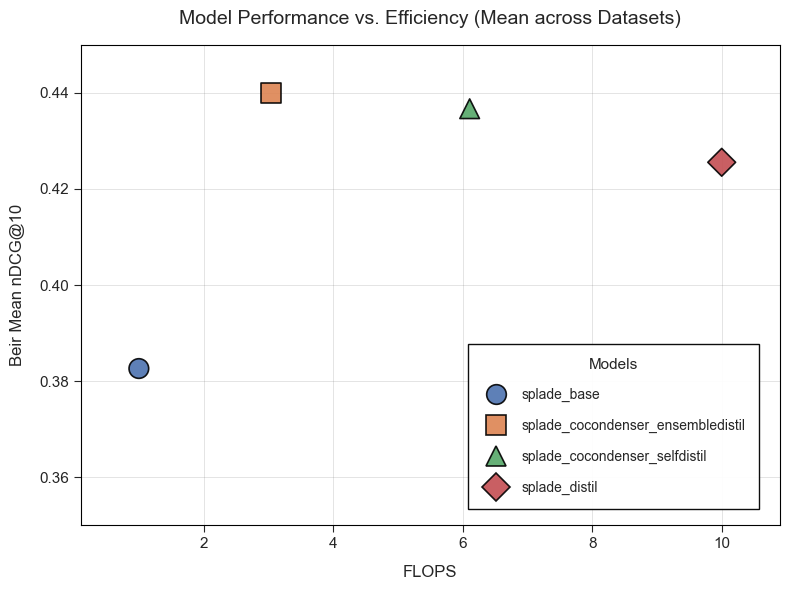

In [76]:
import numpy as np

# Remove any model that contains "bm25"
df = full_df[~full_df['Model'].str.contains('bm25', case=False, na=False)]

# Calculate means per Model
grouped_df = df.groupby('Model')[['nDCG@10', 'Avg_FLOPS']].mean().reset_index()

# We normalize the 'Avg_FLOPS' column to be between 1 and 10 relative to the current models.
min_flops = grouped_df['Avg_FLOPS'].min()
max_flops = grouped_df['Avg_FLOPS'].max()

# Formula: NewValue = 1 + ( (Value - Min) * (10 - 1) ) / (Max - Min)
grouped_df['Normalized_FLOPS'] = 1 + ((grouped_df['Avg_FLOPS'] - min_flops) * 9) / (max_flops - min_flops)

# Use a white background style similar to the paper
plt.style.use('seaborn-v0_8-whitegrid') 
fig, ax = plt.subplots(figsize=(8, 6))

# Define distinct markers matching the paper style
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '<', '>']
# Ensure we have enough markers for the models
if len(grouped_df) > len(markers):
    markers = markers * 2 

# Create the scatter plot
sns.scatterplot(
    data=grouped_df,
    x='Normalized_FLOPS',
    y='nDCG@10',
    hue='Model',
    style='Model',
    markers=markers[:len(grouped_df)],
    s=200,              # Marker size
    palette='deep',     # Color palette similar to paper
    alpha=0.9,
    edgecolor='black',
    linewidth=1.2,
    ax=ax,
    legend='full'
)

# Configure grid to match paper style (lighter, behind data)
ax.grid(True, which='major', linestyle='-', linewidth=0.5, color='gray', alpha=0.3, zorder=0)
ax.set_axisbelow(True)  # Ensure grid is behind data points

# Keep all spines visible like in the paper
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color('black')

# Add Labels with style matching the paper
ax.set_title('Model Performance vs. Efficiency (Mean across Datasets)', 
             fontsize=14, fontweight='normal', pad=15)
ax.set_xlabel('FLOPS', fontsize=12, labelpad=10)
ax.set_ylabel('Beir Mean nDCG@10', fontsize=12, labelpad=10)

# Customize Ticks
ax.tick_params(axis='both', which='major', labelsize=11, direction='out', length=5)

# Legend Configuration - BOTTOM RIGHT with more spacing
# Position it at the bottom right
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=labels,
    loc='lower right',               # Position at bottom right
    bbox_to_anchor=(0.98, 0.02),     # Fine-tune position (slightly inside the plot)
    ncol=1,                          # One column
    title='Models',
    title_fontsize=11,
    fontsize=10,
    frameon=True,
    fancybox=False,                  # Square corners like paper
    edgecolor='black',
    framealpha=0.95,                 # Slightly transparent background
    borderpad=1.0,                   # Padding inside the legend box
    labelspacing=1.2,                # Vertical space between entries
    columnspacing=2.0,               # Horizontal space between columns
    handletextpad=0.8,               # Space between marker and text
    handlelength=2.0                 # Length of the marker line
)

# Set fixed Y-axis limits from 0.35 to 0.45 for better visualization
ax.set_ylim(0.35, 0.45)

# Add some padding to the X-axis limits for better visualization
x_range = grouped_df['Normalized_FLOPS'].max() - grouped_df['Normalized_FLOPS'].min()
ax.set_xlim(grouped_df['Normalized_FLOPS'].min() - 0.1*x_range, 
            grouped_df['Normalized_FLOPS'].max() + 0.1*x_range)

plt.tight_layout()
plt.show()

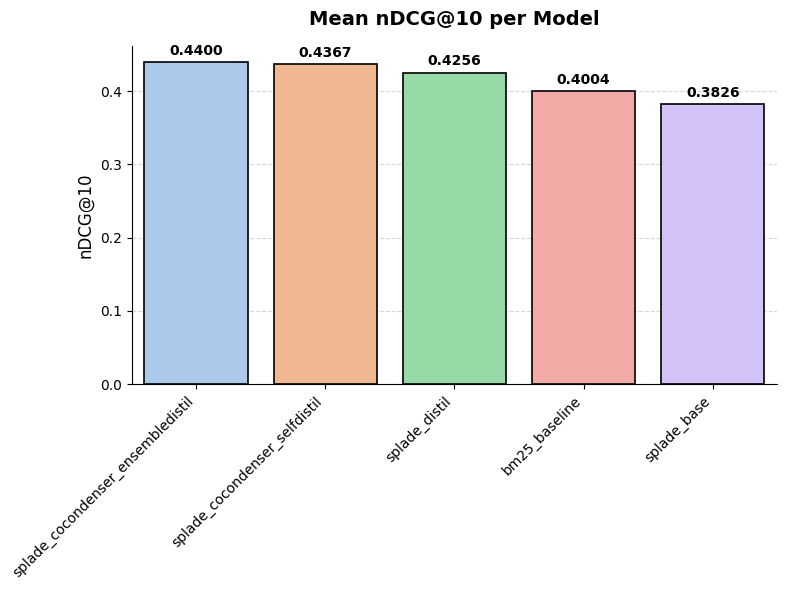

In [73]:
# Plot to visualize the mean nDCG@10 for all the models

# 1. Calculate Mean MRR per Model and Sort
metric_col = 'nDCG@10' 

grouped_df = full_df.groupby('Model')[metric_col].mean().reset_index()
grouped_df = grouped_df.sort_values(metric_col, ascending=False)

# 2. Plotting Setup (Academic Style)
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))

# Create Bar Plot
sns.barplot(
    data=grouped_df,
    x='Model',
    y=metric_col,
    hue='Model',
    palette='pastel',  # Stessa palette per coerenza visiva
    edgecolor='black',
    linewidth=1.2,
    ax=ax,
    zorder=3,
    legend=False
)

# 3. Aesthetics
ax.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title(f'Mean {metric_col} per Model', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel(metric_col, fontsize=12)
ax.set_xlabel('') 

# Rotate x-labels for readability
plt.xticks(rotation=45, ha='right', fontsize=10)

# 4. Add Values on Top of Bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.4f}', 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', 
        xytext=(0, 8), 
        textcoords='offset points',
        fontsize=10, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

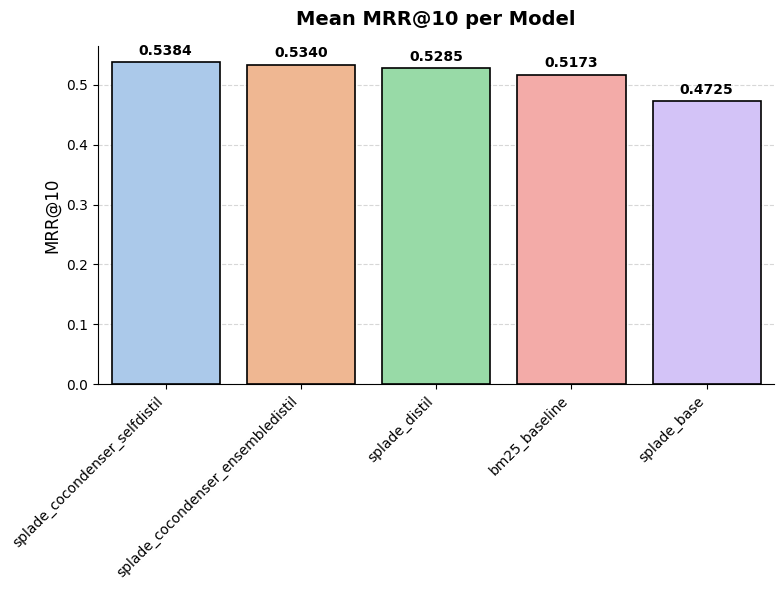

In [46]:
# Plot to visualize the mean MRR for all the models

# 1. Calculate Mean MRR per Model and Sort
metric_col = 'MRR@10' 

grouped_df = full_df.groupby('Model')[metric_col].mean().reset_index()
grouped_df = grouped_df.sort_values(metric_col, ascending=False)

# 2. Plotting Setup (Academic Style)
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))

# Create Bar Plot
sns.barplot(
    data=grouped_df,
    x='Model',
    y=metric_col,
    hue='Model',
    palette='pastel',  # Stessa palette per coerenza visiva
    edgecolor='black',
    linewidth=1.2,
    ax=ax,
    zorder=3,
    legend=False
)

# 3. Aesthetics
ax.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title(f'Mean {metric_col} per Model', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel(metric_col, fontsize=12)
ax.set_xlabel('') 

# Rotate x-labels for readability
plt.xticks(rotation=45, ha='right', fontsize=10)

# 4. Add Values on Top of Bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.4f}', 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', 
        xytext=(0, 8), 
        textcoords='offset points',
        fontsize=10, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

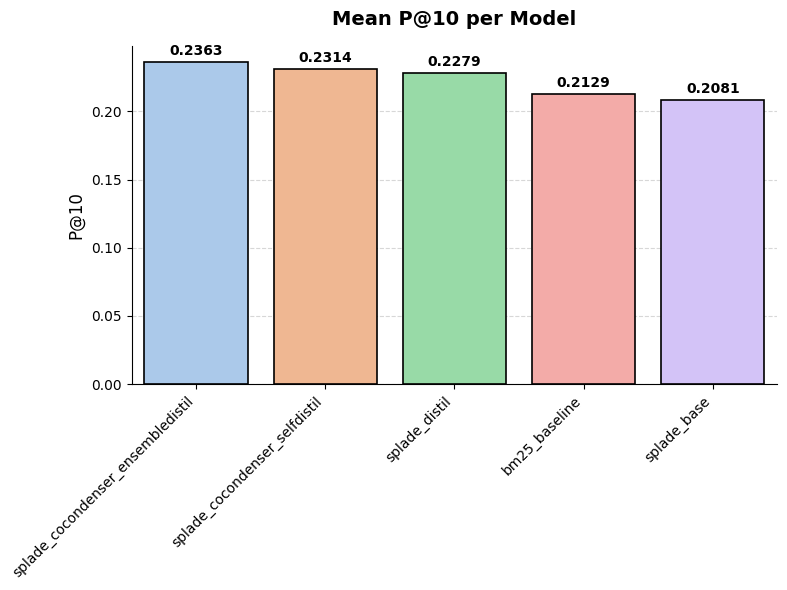

In [48]:
# Plot to visualize the mean Precision for all the models

# 1. Calculate Mean Precision per Model and Sort
metric_col = 'P@10' 

grouped_df = full_df.groupby('Model')[metric_col].mean().reset_index()
grouped_df = grouped_df.sort_values(metric_col, ascending=False)

# 2. Plotting Setup (Academic Style)
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))

# Create Bar Plot
sns.barplot(
    data=grouped_df,
    x='Model',
    y=metric_col,
    hue='Model',
    palette='pastel',  # Stessa palette per coerenza visiva
    edgecolor='black',
    linewidth=1.2,
    ax=ax,
    zorder=3,
    legend=False
)

# 3. Aesthetics
ax.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title(f'Mean {metric_col} per Model', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel(metric_col, fontsize=12)
ax.set_xlabel('') 

# Rotate x-labels for readability
plt.xticks(rotation=45, ha='right', fontsize=10)

# 4. Add Values on Top of Bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.4f}', 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', 
        xytext=(0, 8), 
        textcoords='offset points',
        fontsize=10, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

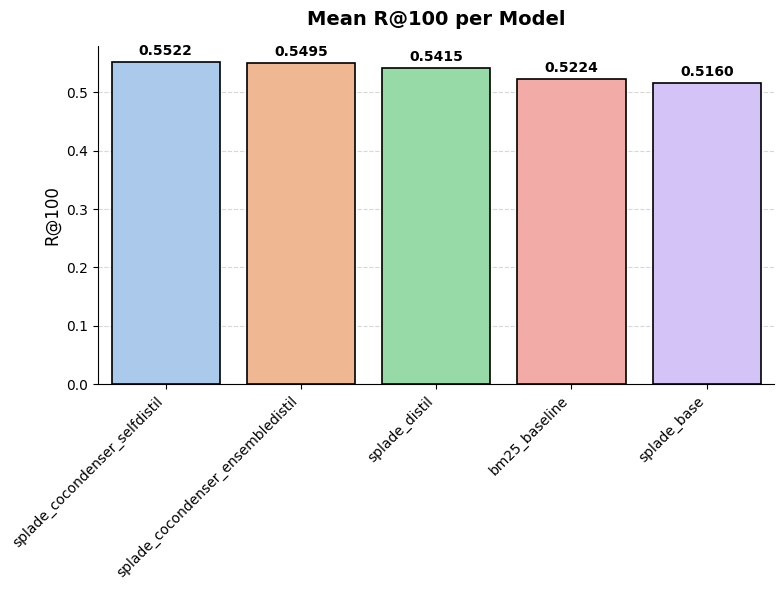

In [67]:
# Plot to visualize the mean Recall 100 for all the models

# 1. Calculate Mean Recall per Model and Sort
metric_col = 'R@100' 

grouped_df = full_df.groupby('Model')[metric_col].mean().reset_index()
grouped_df = grouped_df.sort_values(metric_col, ascending=False)

# 2. Plotting Setup (Academic Style)
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))

# Create Bar Plot
sns.barplot(
    data=grouped_df,
    x='Model',
    y=metric_col,
    hue='Model',
    palette='pastel',  # Stessa palette per coerenza visiva
    edgecolor='black',
    linewidth=1.2,
    ax=ax,
    zorder=3,
    legend=False
)

# 3. Aesthetics
ax.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title(f'Mean {metric_col} per Model', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel(metric_col, fontsize=12)
ax.set_xlabel('') 

# Rotate x-labels for readability
plt.xticks(rotation=45, ha='right', fontsize=10)

# 4. Add Values on Top of Bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.4f}', 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', 
        xytext=(0, 8), 
        textcoords='offset points',
        fontsize=10, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

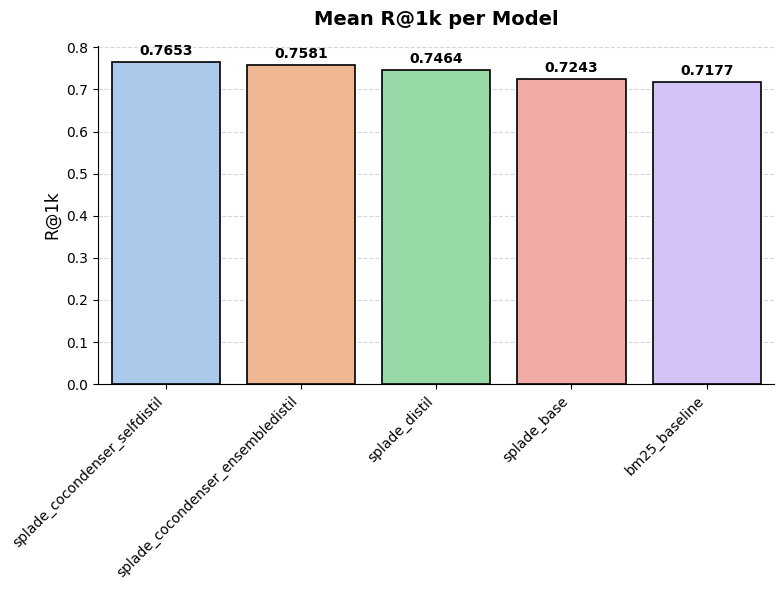

In [ ]:
# Plot to visualize the mean Recall 1k for all the models

# 1. Calculate Mean Recall per Model and Sort
metric_col = 'R@1k' 

grouped_df = full_df.groupby('Model')[metric_col].mean().reset_index()
grouped_df = grouped_df.sort_values(metric_col, ascending=False)

# 2. Plotting Setup (Academic Style)
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))

# Create Bar Plot
sns.barplot(
    data=grouped_df,
    x='Model',
    y=metric_col,
    hue='Model',
    palette='pastel',
    edgecolor='black',
    linewidth=1.2,
    ax=ax,
    zorder=3,
    legend=False
)

# 3. Aesthetics
ax.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title(f'Mean {metric_col} per Model', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel(metric_col, fontsize=12)
ax.set_xlabel('') 

# Rotate x-labels for readability
plt.xticks(rotation=45, ha='right', fontsize=10)

# 4. Add Values on Top of Bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.4f}', 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', 
        xytext=(0, 8), 
        textcoords='offset points',
        fontsize=10, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

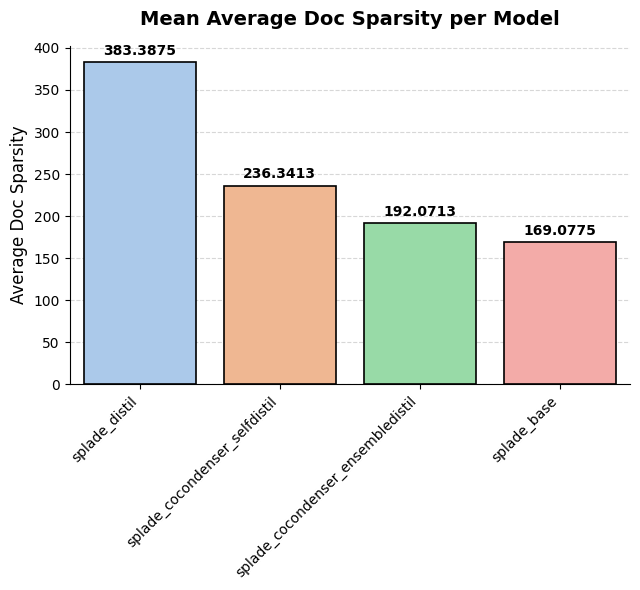

In [70]:
# Plot to visualize the mean Document Sparsity for all the models

metric_col = 'Avg_Doc_Sparsity' 

# Filter out rows where the 'Model' column contains 'bm25' (case insensitive)
df = full_df[~full_df['Model'].str.contains('bm25', case=False, na=False)]

# Calculate mean Average Sparsity per Model
grouped_df = df.groupby('Model')[metric_col].mean().reset_index()

# Sort by Sparsity descending (highest sparsity on the left)
grouped_df = grouped_df.sort_values(metric_col, ascending=False)

# Use default style as base, then customize
plt.style.use('default')
fig, ax = plt.subplots(figsize=(6.5, 6))

# Create Bar Plot
bars = sns.barplot(
    data=grouped_df,
    x='Model',
    y=metric_col,
    hue='Model',
    palette='pastel', # Professional color gradient
    edgecolor='black', # Black border for academic look
    linewidth=1.2,     # Thicker border
    ax=ax,
    zorder=3,           # Ensure bars are on top of grid
    legend=False
)

# 3. Aesthetics
ax.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title(f'Mean Average Doc Sparsity per Model', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("Average Doc Sparsity", fontsize=12)
ax.set_xlabel('') 

# Rotate x-labels for readability
plt.xticks(rotation=45, ha='right', fontsize=10)

# 4. Add Values on Top of Bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.4f}', 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', 
        xytext=(0, 8), 
        textcoords='offset points',
        fontsize=10, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()